<a href="https://colab.research.google.com/github/hectorjimenez12/CC5205_Proyecto/blob/main/Game_ClassificationCNNV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento 3 Proyecto Mineria de datos

In [1]:
import pandas as pd
import numpy as np
import random
import torch
from torch.utils.data import TensorDataset, DataLoader
from PIL import Image
from torchvision import datasets, models, transforms
import time
import copy

import json
import ast

seed =  3495 #5937261 #  #123456

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True


# Cargar datos y descargar imagenes utilizadas

In [2]:
#url = 'https://raw.githubusercontent.com/hectorjimenez12/Mineria_Datos/main/steam.csv'
#dfdata = pd.read_csv(url)
#url = 'https://raw.githubusercontent.com/hectorjimenez12/Mineria_Datos/main/steam_description_data.csv.zip'
#df_descriptions = pd.read_csv(url)
#url = 'https://raw.githubusercontent.com/hectorjimenez12/Mineria_Datos/main/steam_media_data.csv.zip'
url = 'https://raw.githubusercontent.com/hectorjimenez12/Mineria_Datos/main/SteamSpy_Filt_AllData.zip'
dfmedia = pd.read_csv(url)

In [3]:
#import requests
#def get_data_appid(appid):
#    url = 'http://store.steampowered.com/api/appdetails/'
#    parameters = {"appids": appid}
#    response = requests.get(url=url, headers={'User-Agent': 'Mozilla/5.0'},params = parameters)
#    if response:
#        return response.json()
#    else:
#        return None
#idsdel = []
#for appid in dfmedia.appid:
#  dataapp = get_data_appid(appid)
#  if dataapp is not None:
#    dataapp = dataapp[str(appid)]['data']
#    datestr = dataapp['release_date']['date'].split(',')[-1]
#    datestr = int(datestr.split()[-1])
#    if datestr > 2021:
#      idsdel.append(appid)
#      print(appid)
#dataapp.keys()

In [4]:
dfmedia

,Unnamed: 0,index,appid,name,owners,screenshots,priceclp,year
0,0,1,2870,X Rebirth,500000-1000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",15500.00,2013
1,1,2,4720,Condemned: Criminal Origins,200000-500000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",7500.00,2012
2,2,3,4920,Natural Selection 2,1000000-2000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",3000.00,2012
3,4,6,8870,BioShock Infinite,5000000-10000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",14500.00,2013
4,5,7,8980,Borderlands Game of the Year,1000000-2000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",18990.00,2023
...,...,...,...,...,...,...,...,...
11376,19590,25851,2296990,We Were Here Expeditions: The FriendShip,500000-1000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",2400.00,2023
11377,20062,26387,2378900,The Coffin of Andy and Leyley,200000-500000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",5750.00,2023
11378,20063,26388,2379390,Tom Clancy’s Rainbow Six Extraction,200000-500000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",30999.00,2023
11379,20190,26530,2399830,ARK: Survival Ascended,1000000-2000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",41600.00,2023


In [5]:
#dfdata.groupby('owners').count().loc[:,'name'].sort_values().plot.bar()
#ELIMINAR LOS DE CLASE entre 100000 y 200000

dfmedia = dfmedia[~ dfmedia.owners.isin(['100000-200000']) ]
dfmedia = dfmedia.reset_index(level=0,drop=True)
dfmedia

,Unnamed: 0,index,appid,name,owners,screenshots,priceclp,year
0,0,1,2870,X Rebirth,500000-1000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",15500.00,2013
1,1,2,4720,Condemned: Criminal Origins,200000-500000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",7500.00,2012
2,2,3,4920,Natural Selection 2,1000000-2000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",3000.00,2012
3,4,6,8870,BioShock Infinite,5000000-10000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",14500.00,2013
4,5,7,8980,Borderlands Game of the Year,1000000-2000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",18990.00,2023
...,...,...,...,...,...,...,...,...
11376,19590,25851,2296990,We Were Here Expeditions: The FriendShip,500000-1000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",2400.00,2023
11377,20062,26387,2378900,The Coffin of Andy and Leyley,200000-500000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",5750.00,2023
11378,20063,26388,2379390,Tom Clancy’s Rainbow Six Extraction,200000-500000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",30999.00,2023
11379,20190,26530,2399830,ARK: Survival Ascended,1000000-2000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",41600.00,2023


In [6]:
def class_owners(strowners):
  own_int = int(strowners.split('-')[0])
  if own_int > 100000:
    return 'Hsell'
  else:
    return 'Lsell'
class_owners(dfmedia.owners[2])

'Hsell'

In [7]:
from google.colab import drive
drive.mount('/content/gdrive')
import os


Mounted at /content/gdrive


Cambiar esto

In [8]:
ids = os.listdir('/content/gdrive/MyDrive/U/S1/Mineria_Datos/Proyecto/Hito3/imagenes')

In [9]:
ids1 = [ int(i.split('.')[0].split('header')[1]) for i in ids if i[0:3] != 'add']
ids2 = [ int(i.split('.')[0].split('add')[1]) for i in ids if i[0:3] == 'add']
print(len(ids1),len(ids2))

7773 7738


In [10]:
ids = [i for i in ids1 if i in ids2] #[ int(i.split('.')[0].split('header')[1]) if i[0:3] != 'add' else int(i.split('.')[0].split('add')[1]) for i in ids]
dfmedia = dfmedia[dfmedia.appid.isin(ids)]
dfmedia = dfmedia.reset_index(level=0,drop=True)
dfmedia
#Image.open('/content/gdrive/MyDrive/U/S1/Mineria_Datos/Proyecto/Hito3/imagenes/header1482450.jpg')

,Unnamed: 0,index,appid,name,owners,screenshots,priceclp,year
0,0,1,2870,X Rebirth,500000-1000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",15500.00,2013
1,1,2,4720,Condemned: Criminal Origins,200000-500000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",7500.00,2012
2,2,3,4920,Natural Selection 2,1000000-2000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",3000.00,2012
3,4,6,8870,BioShock Infinite,5000000-10000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",14500.00,2013
4,5,7,8980,Borderlands Game of the Year,1000000-2000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",18990.00,2023
...,...,...,...,...,...,...,...,...
5085,19590,25851,2296990,We Were Here Expeditions: The FriendShip,500000-1000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",2400.00,2023
5086,20062,26387,2378900,The Coffin of Andy and Leyley,200000-500000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",5750.00,2023
5087,20063,26388,2379390,Tom Clancy’s Rainbow Six Extraction,200000-500000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",30999.00,2023
5088,20190,26530,2399830,ARK: Survival Ascended,1000000-2000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",41600.00,2023


Text(0.5, 0, '')

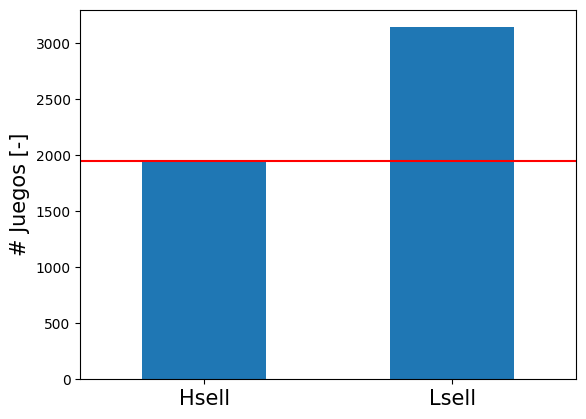

In [11]:
dfmedia['owners_label'] = [ class_owners(i) for i in dfmedia.owners ]

import matplotlib.pyplot as plt
dfmedia.groupby('owners_label').count().loc[:,'name'].plot.bar()
plt.axhline(y = 1949, color = 'r', linestyle = '-')
plt.ylabel('# Juegos [-]',fontsize = 15)
plt.xticks(rotation=0,fontsize = 15)
plt.xlabel('')

Seleccionamos un sample de 500 por cada clase

In [12]:
Nsample  = 1900
labels   = ['Hsell','Lsell']
list_ids = [ random.sample(list(dfmedia.index[dfmedia.owners_label.isin([i])]),k=Nsample) for i in labels ]
dfsample = dfmedia.loc[ sum(list_ids,[]) , ['appid','name','owners','owners_label','priceclp','screenshots'] ]
dfsample

,appid,name,owners,owners_label,priceclp,screenshots
924,359900,The Incredible Adventures of Van Helsing III,200000-500000,Hsell,3550.0,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
52,115800,Owlboy,200000-500000,Hsell,12000.0,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
468,270790,Etherlords II,200000-500000,Hsell,3000.0,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
1480,460810,Vanquish,500000-1000000,Hsell,14500.0,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
599,298520,Orbital Gear,200000-500000,Hsell,5500.0,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
...,...,...,...,...,...,...
2176,655200,Arena,0-20000,Lsell,1900.0,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
4617,1303170,MelDEV Power Boat Racing,0-20000,Lsell,6100.0,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
5007,1480400,Ramses: Rise of Empire,0-20000,Lsell,1650.0,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
670,312010,Bird Assassin,0-20000,Lsell,1300.0,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."


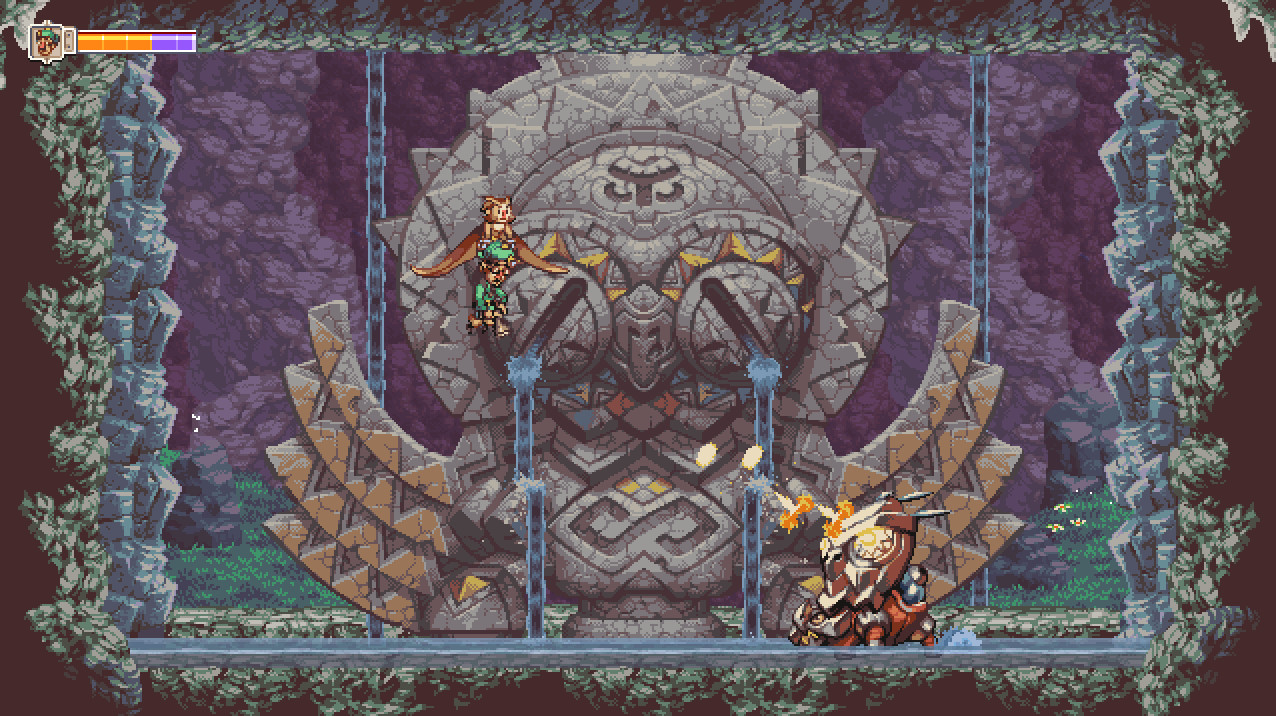

In [13]:
Image.open('/content/gdrive/MyDrive/U/S1/Mineria_Datos/Proyecto/Hito3/imagenes/add'+str(dfsample.appid.iloc[1])+'.png')

# 1 Definicion de clases y transformaciones


In [14]:
import torchvision
class GamesDataset(torch.utils.data.Dataset):
  def __init__(self,root , appids, prices, labels, transform):
    self.transform = transform
    self.root = root
    self.class2idx = dict()
    self.class2idx['Lsell'] = 0
    self.class2idx['Hsell'] = 1
    self.classes = ['Lsell','Hsell']
    self.labels = labels
    self.prices = prices

    self.header_images = []
    self.add_images  = []

    for id_image in appids:
      self.header_images.append(self.root + 'header'  + str(id_image) +'.jpg')
      self.add_images.append(self.root + 'add'  + str(id_image) +'.png')

  def __len__(self):
    return len(self.header_images)

  def __getitem__(self, idx):
    header = Image.open( self.header_images[idx] ).convert('RGB')
    add = Image.open( self.add_images[idx] ).convert('RGB')
    label = self.class2idx[self.labels[idx]]

    if self.transform:
      header = self.transform(header)
      add    = self.transform(add)

    return header, add, torch.tensor(self.prices[idx],dtype = torch.float32 ), label

In [15]:
transforms = torchvision.transforms.Compose([torchvision.transforms.Resize(100),
                                             torchvision.transforms.CenterCrop(160),
                                             torchvision.transforms.ToTensor() ] )
#torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
#list_img = [i[1] for i in list_img]

Split dataset en train, validation y test

In [16]:
from sklearn.model_selection import train_test_split
ylabel = list(dfsample['owners_label'])
appids_prices = np.array(dfsample.loc[:,['appid','priceclp']])
X_train, X_test, Y_train, Y_test = train_test_split( appids_prices , ylabel, test_size = 0.2, stratify = ylabel , random_state=seed)
X_train, X_val , Y_train, Y_val  = train_test_split(X_train, Y_train, test_size=10/80, stratify= Y_train, random_state=seed)

In [17]:
#ipos = 556
#print(dfsample.iloc[ipos])
#print(ylabel[ipos])
#list_img[ipos][0]

In [18]:
# crear Games datasets
train_dataset = GamesDataset(root='/content/gdrive/MyDrive/U/S1/Mineria_Datos/Proyecto/Hito3/imagenes/',
                             appids = X_train[:,0].astype(int) , prices= X_train[:,1].astype(int),
                             labels = Y_train , transform = transforms)
valid_dataset = GamesDataset(root='/content/gdrive/MyDrive/U/S1/Mineria_Datos/Proyecto/Hito3/imagenes/',
                             appids = X_val[:,0].astype(int) , prices= X_val[:,1].astype(int),
                             labels = Y_val , transform = transforms)
test_dataset  = GamesDataset(root='/content/gdrive/MyDrive/U/S1/Mineria_Datos/Proyecto/Hito3/imagenes/',
                             appids = X_test[:,0].astype(int) , prices= X_test[:,1].astype(int),
                             labels = Y_test , transform = transforms)
# dataloaders
batch_size = 20

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
valid_loader = DataLoader(valid_dataset, shuffle=True, batch_size=batch_size)
test_loader  = DataLoader(test_dataset, shuffle=False, batch_size=1)

In [19]:
#import matplotlib.pyplot as plt
#for header, add, price, test_labels in train_loader:
#    sample_header = header[0]    # Reshape them according to your needs.
#    sample_add = add[0]

#sample_image.shape
#plt.imshow(sample_header.to('cpu').numpy()[2,:,:])
#plt.imshow(sample_add.to('cpu').numpy()[2,:,:])

In [20]:
train_on_gpu=torch.cuda.is_available()
if(train_on_gpu):
    print('Training on GPU.')
else:
    print('No GPU available, training on CPU.')

Training on GPU.


In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# 3. CNN neural model

Basic convolution

In [22]:
import torchsummary as ts
from torch.nn import Module, Sequential, LeakyReLU, Conv2d, BatchNorm2d, AvgPool2d, MaxPool2d, AdaptiveAvgPool2d, Linear
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

learning_rate=0.0001

In [23]:
class MLP(nn.Module):
  def __init__(self, input_dim, output_dim,dlayers):
    super().__init__()
    self.nlayers = 2
    self.fc1 = nn.Linear(input_dim, list(dlayers.items())[0][1].weight.shape[1] ) #capa de entrada
    for iname,hlayer in dlayers.items(): # capas ocultas
      setattr(self,iname,hlayer)
      self.nlayers = self.nlayers+ 1
    setattr(self,'fc'+str(self.nlayers),nn.Linear(hlayer.weight.shape[0], output_dim)) # salida a funcion de activacion
  def forward(self, input):
    batch_size = input.shape[0]
    input = input.view(batch_size, -1)
    #print(input)
    next_input = F.relu(self.fc1(input))
    for ilayer in range(self.nlayers - 2):
      next_input = F.relu( getattr(self,'fc'+str(ilayer+2))(next_input) )
    y_pred =  getattr(self,'fc'+str(self.nlayers))(next_input)
    #print(y_pred)
    return y_pred

#MLP_model = MLP(input_dim = 1 , output_dim = 5,dlayers={'fc2':nn.Linear(50, 25)})
#MLP_model(input = torch.tensor([7],dtype = torch.float32 ))
#print(MLP_model)
#ts.summary(MLP_model.to(device), (1,1,1), device='cuda') #-1 representa el tamaño de batch


In [24]:
class BasicConv2d(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, **kwargs) -> None:
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 16, kernel_size=3,padding = 1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3,padding = 1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, out_channels, kernel_size=3)
        self.bn3 = nn.BatchNorm2d(out_channels)
    def forward(self, x):
        x = F.relu(F.max_pool2d(self.bn1(self.conv1(x)) , 2) )
        x = F.relu( F.max_pool2d(self.bn2(self.conv2(x)) , 2) )
        return F.relu( self.bn3(self.conv3(x)) )

In [25]:
class Net(nn.Module):
  def __init__(self):
    super(Net,self).__init__()
    self.branch_header = BasicConv2d(3, 64, kernel_size=3, stride=1, padding=1)  # 160 --> 80 --> 40
    self.branch_add    = BasicConv2d(3, 64, kernel_size=3, stride=1, padding=1)  # 64 channels
    self.branch_price  = MLP(input_dim = 1 , output_dim = 5,dlayers={'fc2':nn.Linear(50, 25)}) #FCL
    self.fc1 = nn.Linear( 38*38*64*2 + 5 , 100) #"256"
    self.fc2 = nn.Linear(100,2)
    #self.sig = nn.Sigmoid()
  def forward(self, im1,im2,p):
    # header --> -1, 224/2 x 224/2 x 64, add--> -1, 224/2 x 224/2 x 64, price --> -1, 10
    outputs              = [self.branch_header(im1), self.branch_add(im2), self.branch_price(p)]
    #for i,out in enumerate(outputs):
    #  print(out.shape)
    #flattening and concat
    outputs[0] = outputs[0].view(-1, 38*38*64 )
    outputs[1] = outputs[1].view(-1, 38*38*64 )
    embedd_cat = torch.cat(outputs, 1) #
    #output = embedd_cat.view(-1, 10 )
    x = F.relu(self.fc1(embedd_cat))
    x = self.fc2(x)
    return x

model = Net()
model = model.to(device)
criterion = nn.CrossEntropyLoss() #nn.BCELoss()
optimizer = torch.optim.Adam( model.parameters(), lr=learning_rate)
exp_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

In [26]:
#https://pypi.org/project/torch-summary/
#print(network)
#ts.summary(network.to(device), [(3, 160, 160),(3, 160, 160),(1,1,1)] , device='cuda') #-1 representa el tamaño de batch

In [27]:
import torch.nn.functional as F
def train_model(model, criterio, optimizer, scheduler, num_epochs = 25):
  since = time.time()

  trainacc    = []
  trainlosses = []
  vallosses   = []
  valacc      = []

  best_model_wts = copy.deepcopy(model.state_dict())
  best_acc = 0.0

  for epoch in range(num_epochs):
    print('Epoch {}/{}'.format(epoch, num_epochs-1))
    print('-' * 10)

    #Train model
    scheduler.step()
    model.train()

    running_loss = 0.0
    running_corrects = 0.0

    for batchId, (data1,data2,data3,labels) in enumerate(train_loader):
      data1 = data1.to(device)
      data2 = data2.to(device)
      data3 = data3.to(device)
      labels = labels.to(device)

      optimizer.zero_grad()

      outputs = model(data1,data2,data3)
      #if batchId == 0:
        #print(outputs)
        #print(preds)
        #print(labels)
        #torch.max(outputs, 1)
        #print(outputs.squeeze())
        #print(torch.round(outputs.squeeze(),decimals=0))

      _, preds = torch.max(outputs, 1)
      loss = criterio(outputs, labels)
      loss.backward()
      optimizer.step()

      #preds = torch.round(outputs.squeeze(),decimals=0)
      running_loss += loss.item() * data1.size(0)
      running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss /len(train_dataset)
    epoch_acc_train = running_corrects.double() / len(train_dataset)
    trainlosses.append(epoch_loss)
    trainacc.append(epoch_acc_train)
    print('Train Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc_train))

    #Validation
    model.eval()
    running_loss = 0.0
    running_corrects = 0.0
    for batchId, (data1,data2,data3,labels) in enumerate(valid_loader):
      data1 = data1.to(device)
      data2 = data2.to(device)
      data3 = data3.to(device)
      labels = labels.to(device)

      with torch.set_grad_enabled(False):
        outputs = model(data1,data2,data3)
        outputs = F.softmax(y_pred, dim = -1)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

      running_loss += loss.item() * data1.size(0)
      running_corrects += torch.sum(preds == labels.data)

    epoch_loss_val = running_loss /len(valid_dataset)
    epoch_acc_val = running_corrects.double() / len(valid_dataset)

    vallosses.append(epoch_loss_val)
    valacc.append(epoch_acc_val)
    print('Val Loss: {:.4f} Acc Val: {:.4f}'.format(epoch_loss_val, epoch_acc_val))

    if epoch_acc_val - epoch_acc_train < - 0.1:
      print('Stop Training')
      model.load_state_dict(best_model_wts)
      return model, trainacc, trainlosses, vallosses, valacc

    if epoch_acc_val > best_acc:
        best_acc = epoch_acc_val
        best_model_wts = copy.deepcopy(model.state_dict())

  time_elapsed = time.time() - since
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed//60, time_elapsed % 60))
  print('Best val accucary: {:.4f}'.format(best_acc))

  model.load_state_dict(best_model_wts)
  return model, trainacc, trainlosses, vallosses, valacc

def test_model(model,criterio):
    model.eval()
    running_loss = 0.0
    running_corrects = 0.0
    for batchId, (data1,data2,data3,labels) in enumerate(test_loader):
      data1 = data1.to(device)
      data2 = data2.to(device)
      data3 = data3.to(device)
      labels = labels.to(device)

      with torch.set_grad_enabled(False):
        outputs = model(data1,data2,data3)
        outputs = F.softmax(y_pred, dim = -1)
        _, preds = torch.max(outputs, 1)
        loss = criterio(outputs, labels)

      running_loss += loss.item() * data1.size(0)
      running_corrects += torch.sum(preds == labels.data)

    epoch_loss_test = running_loss /len(test_dataset)
    epoch_acc_test = running_corrects.double() / len(test_dataset)

    return epoch_acc_test



In [28]:
#test(model)
modeltest, trainacc, trainlosses, vallosses, valacc = train_model(model,criterio = criterion,optimizer= optimizer, scheduler= exp_lr_scheduler ,num_epochs=5)


Epoch 0/4
----------


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:136: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "


Train Loss: 2.1502 Acc: 0.6124
Val Loss: 0.8389 Acc Val: 0.5763
Epoch 1/4
----------
Train Loss: 0.5318 Acc: 0.7429
Val Loss: 0.5992 Acc Val: 0.6789
Epoch 2/4
----------
Train Loss: 0.4296 Acc: 0.8079
Val Loss: 0.6578 Acc Val: 0.6789
Stop Training


In [29]:
test_model(modeltest,criterion)


tensor(0.6711, device='cuda:0', dtype=torch.float64)

In [33]:
trainacc, trainlosses, vallosses, valacc

[tensor(0.6124, device='cuda:0', dtype=torch.float64),
 tensor(0.7429, device='cuda:0', dtype=torch.float64),
 tensor(0.8079, device='cuda:0', dtype=torch.float64)]

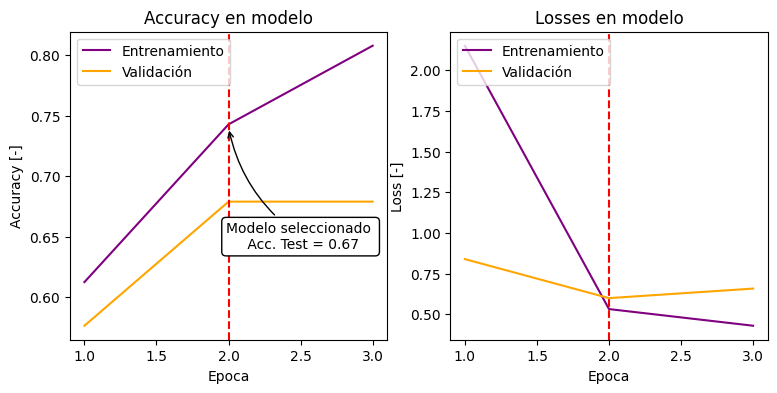

In [76]:
fig, ax = plt.subplots(1,2,figsize=(9,4))
ax[0].plot(np.array(range(1,len(trainacc)+1)).astype(int),[ float(i.cpu().numpy()) for i in trainacc],color='purple')
ax[0].plot(np.array(range(1,len(trainacc)+1)).astype(int),[ float(i.cpu().numpy()) for i in valacc],color='orange')
ax[0].axvline(x = 2, color = 'r', linestyle = '--')
ax[0].set_title('Accuracy en modelo')
ax[0].set_ylabel('Accuracy [-]')
ax[0].set_xlabel('Epoca')
ax[0].legend(['Entrenamiento', 'Validación'], loc='upper left')
ax[0].annotate("Modelo seleccionado \n Acc. Test = 0.67",
            xy=(2, 0.74), xycoords='data',
            xytext=(2.5, 0.65), textcoords='data',
            ha="center", va="center",
            bbox=dict(boxstyle="round", fc="w", ),
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=-0.2"))

ax[1].plot(np.array(range(1,len(trainacc)+1)).astype(int), trainlosses ,color='purple')
ax[1].plot(np.array(range(1,len(trainacc)+1)).astype(int), vallosses ,color='orange')
ax[1].axvline(x = 2, color = 'r', linestyle = '--')
ax[1].set_title('Losses en modelo')
ax[1].set_ylabel('Loss [-]')
ax[1].set_xlabel('Epoca')
ax[1].legend(['Entrenamiento', 'Validación'], loc='upper left')


In [129]:
test_examples = []
transform = torchvision.transforms.ToPILImage()
model.eval()
for batchId, (data1,data2,data3,labels) in enumerate(test_loader):
  data1 = data1.to(device)
  data2 = data2.to(device)
  data3 = data3.to(device)
  labels = labels.to(device)
  with torch.set_grad_enabled(False):
    outputs = model(data1,data2,data3)
    _, preds = torch.max(outputs, 1)
    test_examples.append([transform(data1[0]),transform(data2[0]),float(data3.cpu().numpy()), outputs.cpu().numpy()[0][1] ,labels.cpu().numpy()])


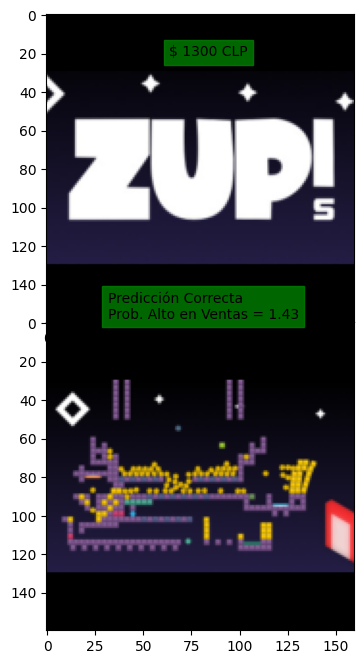

In [145]:
idgame = 44
fig, ax = plt.subplots(2,1,figsize=(4,8))
ax[0].imshow(test_examples[idgame][0])
ax[1].imshow(test_examples[idgame][1])
t = ax[0].text(.4, .90, "$ " + str(test_examples[idgame][2]).split('.')[0] + " CLP" , transform=ax[0].transAxes, ha="left", va="top")
t.set_bbox(dict(facecolor='green', alpha=0.8, edgecolor='green'))
plt.subplots_adjust(hspace=0)
if int(test_examples[idgame][3]) == int(test_examples[idgame][4]):
  t2 = ax[1].text(.2, .1, "Predicción Correcta \nProb. Alto en Ventas = "+ str(round(test_examples[idgame][3],2))  ,
                 transform=ax[0].transAxes, ha="left", va="top")
  t2.set_bbox(dict(facecolor='green', alpha=0.8, edgecolor='green'))
else:
  t2 = ax[1].text(.2, .1, "Predicción Erronea \nProb. Alto en Ventas = "+ str(round(test_examples[idgame][3],2)) ,
                 transform=ax[0].transAxes, ha="left", va="top")
  t2.set_bbox(dict(facecolor='red', alpha=0.8, edgecolor='green'))
